In [1]:
Base.active_project()

"/mnt/idms/home/jungadam/spring/Project.toml"

In [2]:
ENV["LD_LIBRARY_PATH"]

""

In [3]:
using Calibration, BenchmarkTools, CUDA, Statistics, ProgressMeter, Plots, DataFrames, CSV

In [4]:
# set cuda device
CUDA.device!(5)

CuDevice(5): NVIDIA A100-SXM4-40GB

In [5]:
CUDA.allowscalar(false)

In [6]:
function measure_time(M; max_secs = 1)
    bm_naive = @benchmark begin CUDA.@sync Calibration._naive_pairwise_mae($M) end seconds = max_secs
    bm_ours = @benchmark begin CUDA.@sync Calibration.pairwise_mae($M) end seconds = max_secs

    (;bm_naive, bm_ours)
end

measure_time (generic function with 1 method)

In [ ]:
res = []
nn_grid = 500:500:5000
@showprogress for n_samples in nn_grid
    n_observations = 300
    M = CUDA.randn(n_samples, n_observations)
    push!(res, measure_time(M; max_secs = 3*60))
end

In [ ]:
df = DataFrame(
    n_samples = nn_grid, 
    times_naive = getfield.(first.(res), :times) * 1e-9, 
    times_ours = getfield.(last.(res), :times) * 1e-9
    );

In [ ]:
# CSV.write("edk_ablation_study.csv", df)

In [ ]:
df.length_naive = length.(df.times_naive)
df.length_ours = length.(df.times_ours)

df.mean_naive = mean.(df.times_naive)
df.mean_ours = mean.(df.times_ours)

df.std_naive = std.(df.times_naive)
df.std_ours = std.(df.times_ours);

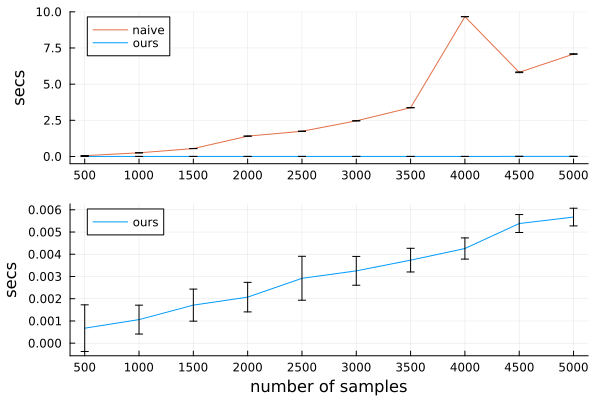

In [24]:
plot(
    begin
        plot(df.n_samples, df.mean_naive, err = df.std_naive, lab = "naive", c = 2)
        plot!(df.n_samples, df.mean_ours, err = df.std_ours, lab = "ours", c = 1, ylim = (-.5, 10))
    end,
    plot(df.n_samples, df.mean_ours, err = df.std_ours, lab = "ours", c = 1, xlab = "number of samples"),
    ylab = "secs", layout = (2,1), link = :x, xticks = df.n_samples,
)
savefig("edk_ablaiton.pdf")
savefig("edk_ablaiton.svg")
plot!()